In [132]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A — Data preparation 

### 1) Loading the datasets

In [72]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

In [73]:
sentiment_df

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [136]:
trader_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25


### 2) Overview of Shape of datasets

In [75]:
print(f"Shape of Sentiment dataset: {sentiment_df.shape}")
print(f"Shape of Trades dataset: {trader_df.shape}")

Shape of Sentiment dataset: (2644, 4)
Shape of Trades dataset: (211224, 16)


### 3) Missing values and duplicates

In [137]:
print(f"Sentiment Missing Values:\n{sentiment_df.isnull().sum()}")
print(f"\nTrades Missing Values:\n{trader_df.isnull().sum()}")

print(f"\nSentiment duplicates:\n{sentiment_df.duplicated().sum()}")
print(f"\nTrades duplicates:\n{trader_df.duplicated().sum()}")

Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

Sentiment duplicates:
0

Trades duplicates:
0


### 4) Converting timestamps

In [138]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date


trader_df['Timestamp IST'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)
trader_df['date'] = trader_df['Timestamp IST'].dt.date

### 5) Merging the datasets

In [78]:
data = trader_df.merge(
    sentiment_df[['date','classification']],
    on='date',
    how='left'
)
data

### 6) Checking for null values after merging

In [83]:
data[data['classification'].isnull()]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification


In [81]:
data = data.sort_values('date')
data['classification'] = data['classification'].ffill()

## Creating Key metrics

### 1) Daily PnL per Trader (Account)

In [87]:
daily_pnl_per_trader = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl_per_trader

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


### 2) Win Rate

In [139]:
data['win'] = data['Closed PnL'] > 0
win_rate = data.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win':'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


### 3) Average Trade Size

In [140]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


### 4) Trades per day

In [141]:
trades_per_day = data.groupby('date').size()

all_dates = pd.date_range(data['date'].min(), data['date'].max())

trades_per_day = trades_per_day.reindex(all_dates, fill_value=0).reset_index()
trades_per_day.columns = ['date','Number of Trades']
trades_per_day

,date,Number of Trades
0,2023-05-01,3
1,2023-05-02,0
2,2023-05-03,0
3,2023-05-04,0
4,2023-05-05,0
...,...,...
727,2025-04-27,337
728,2025-04-28,1379
729,2025-04-29,2243
730,2025-04-30,1113


### 5) Long / Short Ratio

In [142]:
long_short_ratio = data['Side'].value_counts(normalize=True)

print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


# Part B — Analysis

### 1) Performance During Fear vs Greed

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   43.582684
4        Neutral   34.307718


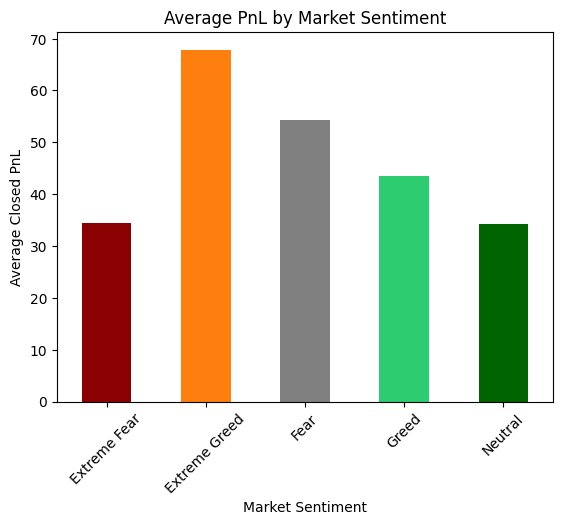

In [148]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()
print(pnl_sentiment)


pnl_sentiment.plot(x='classification', 
                   y='Closed PnL', kind='bar',
                   color = ['#8B0000', '#FF7F0E', '#808080', '#2ECC71', '#006400'],
                   legend = False
                  )
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

  classification    Closed PnL
0   Extreme Fear  -31036.69194
1  Extreme Greed  -10259.46800
2           Fear  -35681.74723
3          Greed -117990.10410
4        Neutral  -24500.00000


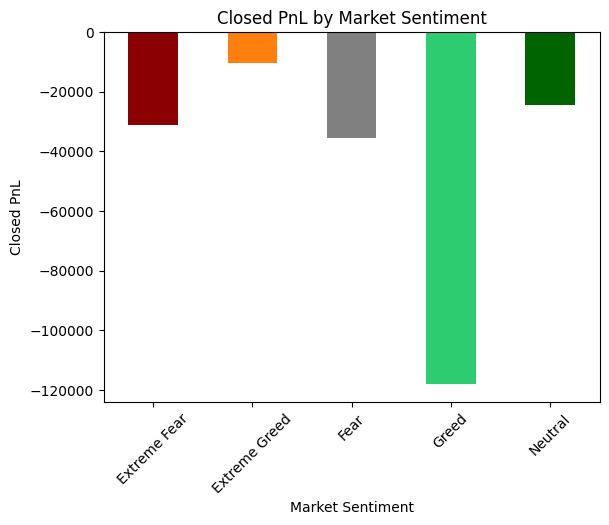

In [149]:
loss_sentiment = data.groupby('classification')['Closed PnL'].min().reset_index()
print(loss_sentiment)

loss_sentiment.plot(x='classification',
                    y='Closed PnL',
                    kind='bar', 
                    legend=False,
                    color = ['#8B0000', '#FF7F0E', '#808080', '#2ECC71', '#006400']
                   )
plt.title("Closed PnL by Market Sentiment")
plt.ylabel("Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

  classification       win
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384901
4        Neutral  0.396991


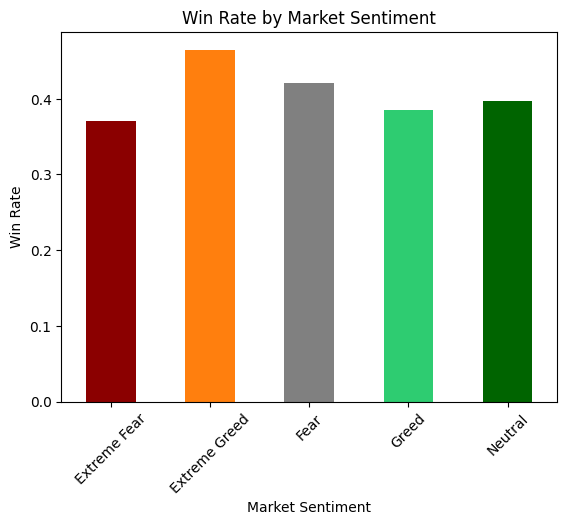

In [151]:
# Win rate by market sentiment 
win_rate_sentiment = data.groupby('classification')['win'].mean().reset_index()
print(win_rate_sentiment)

win_rate_sentiment.plot(x='classification',
                        y='win',
                        kind='bar',
                        legend=False,
                        color = ['#8B0000', '#FF7F0E', '#808080', '#2ECC71', '#006400'])
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### 2) Trader Behavior Based on Sentiment

  classification  Number of Trades
0   Extreme Fear             21400
1  Extreme Greed             39992
2           Fear             61837
3          Greed             50309
4        Neutral             37686


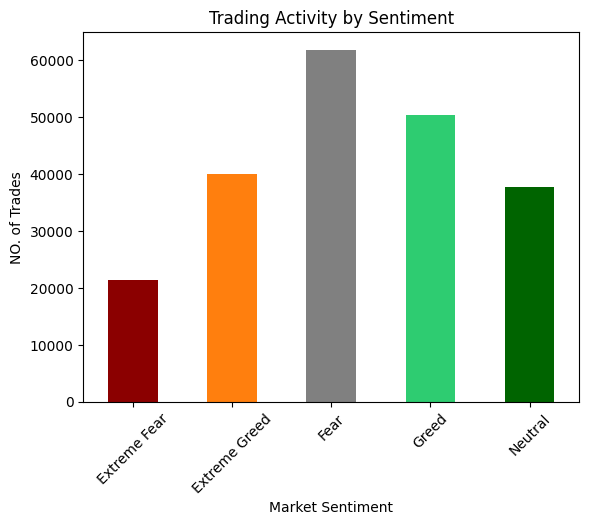

In [154]:
#Trade Frequency
trades_sentiment = data.groupby('classification').size().reset_index(name='Number of Trades')
print(trades_sentiment)

trades_sentiment.plot(x='classification',
                      y='Number of Trades', 
                      kind='bar',
                      color = ['#8B0000', '#FF7F0E', '#808080', '#2ECC71', '#006400'],
                      legend = False)
plt.title("Trading Activity by Sentiment")
plt.ylabel("NO. of Trades")
plt.xlabel("Market Sentiment")
plt.xticks(rotation = 45)
plt.show()

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5737.962662
4        Neutral  4782.732661


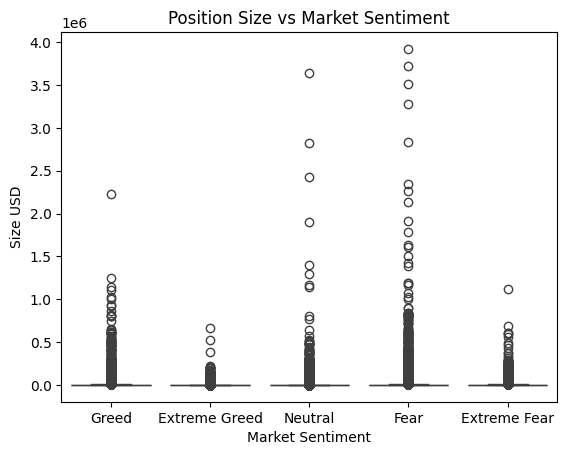

In [156]:
# Position Size by Sentiment
size_sentiment = data.groupby('classification')['Size USD'].mean().reset_index()
print(size_sentiment)

import seaborn as sns

sns.boxplot(x='classification',
            y='Size USD',
            data=data)
plt.title("Position Size vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.show()

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24582  25727
Neutral         18969  18717


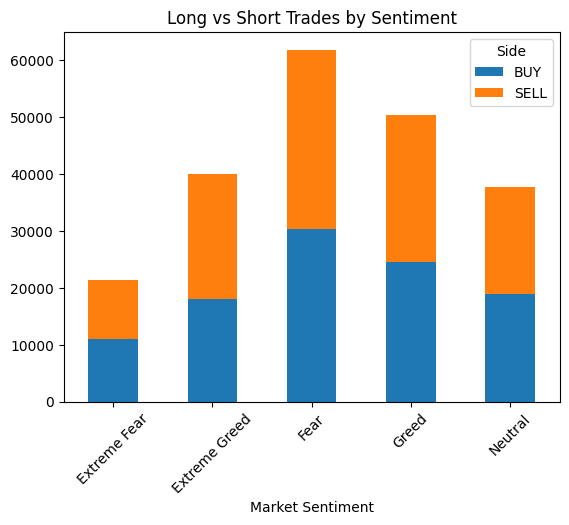

In [157]:
# Long vs Short Bias
long_short = pd.crosstab(data['classification'], data['Side'])
print(long_short)

long_short.plot(kind='bar', stacked=True)
plt.title("Long vs Short Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.show()

### Trader Segmentation

                                       Account  Trades            Segment
0   0x083384f897ee0f19899168e3b1bec365f52a9012    3818    Frequent Trader
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    7280    Frequent Trader
2   0x271b280974205ca63b716753467d5a371de622ab    3809    Frequent Trader
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4   13311    Frequent Trader
4   0x2c229d22b100a7beb69122eed721cee9b24011dd    3239  Infrequent Trader
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     815  Infrequent Trader
6   0x39cef799f8b69da1995852eea189df24eb5cae3c    3589  Infrequent Trader
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     332  Infrequent Trader
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641     383  Infrequent Trader
9   0x430f09841d65beb3f27765503d0f850b8bce7713    1237  Infrequent Trader
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85    8519    Frequent Trader
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    4356    Frequent Trader
12  0x4f93fead39b70a1824f981a54d4e55b2

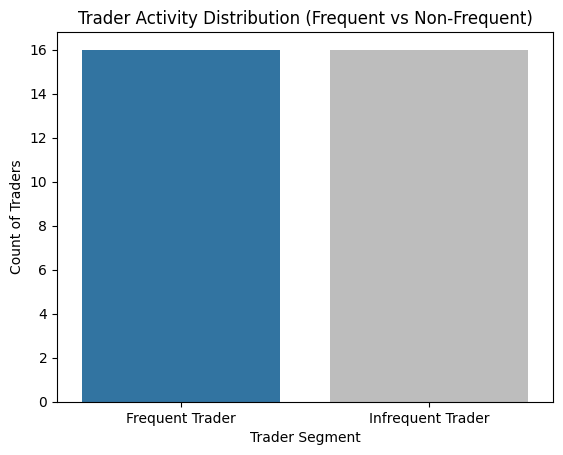

In [167]:
#Segment 1 — Frequent vs Infrequent Traders

trader_activity = data.groupby('Account').size().reset_index(name='Trades')
threshold = trader_activity['Trades'].median()

trader_activity['Segment'] = trader_activity['Trades'].apply(
    lambda x: 'Frequent Trader' if x > threshold else 'Infrequent Trader'
)
print(trader_activity)

sns.countplot(
    data=trader_activity,
    x='Segment',
    hue='Segment',
    palette={
        'Frequent Trader': '#1f77b4',
        'Infrequent Trader': '#bdbdbd'
    }
)
plt.title("Trader Activity Distribution (Frequent vs Non-Frequent)")
plt.ylabel("Count of Traders")
plt.xlabel("Trader Segment")
plt.show()

                                       Account      Size USD      Risk Segment
0   0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734  High Size Trader
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327   Low Size Trader
2   0x271b280974205ca63b716753467d5a371de622ab   8893.000898  High Size Trader
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933   Low Size Trader
4   0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782   Low Size Trader
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   1729.941104   Low Size Trader
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   4790.575486  High Size Trader
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   3445.471265  High Size Trader
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641   5189.367128  High Size Trader
9   0x430f09841d65beb3f27765503d0f850b8bce7713   2397.824753   Low Size Trader
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85    517.528924   Low Size Trader
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   908

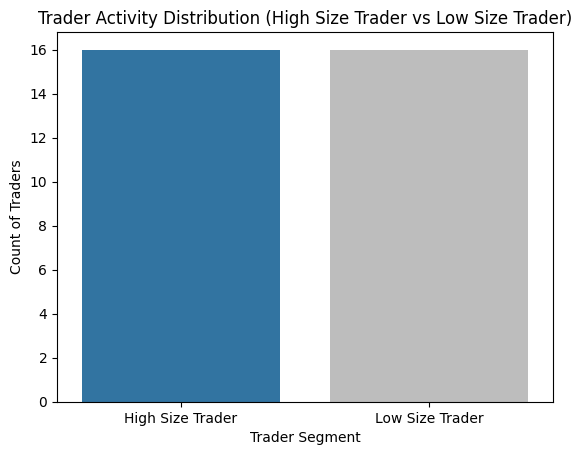

In [168]:
## Segment 2 — High vs Low Risk Traders
avg_size = data.groupby('Account')['Size USD'].mean().reset_index()

size_threshold = avg_size['Size USD'].median()

avg_size['Risk Segment'] = avg_size['Size USD'].apply(
    lambda x: 'High Size Trader' if x > size_threshold else 'Low Size Trader'
)
print(avg_size)

sns.countplot(data = avg_size , x = 'Risk Segment',
             hue='Risk Segment',
             palette={
                    'High Size Trader': '#1f77b4',
                    'Low Size Trader': '#bdbdbd'
    }
)
plt.title("Trader Activity Distribution (High Size Trader vs Low Size Trader)")
plt.ylabel("Count of Traders")
plt.xlabel("Trader Segment")
plt.show()

                                       Account   Closed PnL  \
0   0x083384f897ee0f19899168e3b1bec365f52a9012  4692.452329   
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   134.073473   
2   0x271b280974205ca63b716753467d5a371de622ab   542.182659   
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4   113.269353   
4   0x2c229d22b100a7beb69122eed721cee9b24011dd   255.829091   
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   558.778753   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   730.495484   
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  1279.855788   
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641  2228.336140   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  1649.497580   
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85    88.292842   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   855.354003   
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760   656.693628   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1   639.402444   
14  0x6d6a4b953f202f8df5bed40692e7fd865318264a   468.99

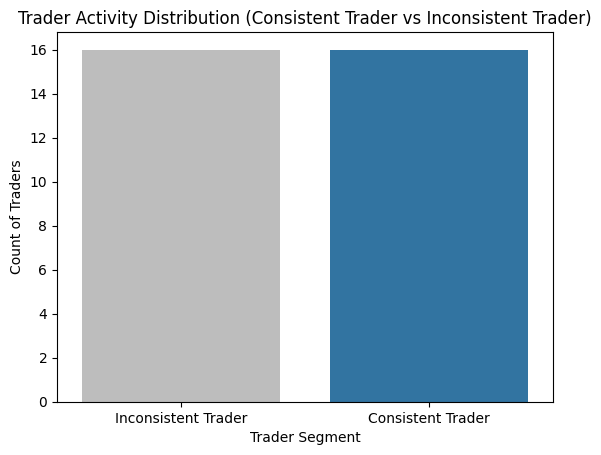

In [170]:
## Segment 3 — Consistent vs Inconsistent Traders

pnl_volatility = data.groupby('Account')['Closed PnL'].std().reset_index()

threshold = pnl_volatility['Closed PnL'].median()

pnl_volatility['Consistency'] = pnl_volatility['Closed PnL'].apply(
    lambda x: 'Consistent Trader' if x < threshold else 'Inconsistent Trader'
)

print(pnl_volatility)

sns.countplot(data = pnl_volatility , x= "Consistency",
             hue='Consistency',
             palette={
                    'Consistent Trader': '#1f77b4',
                    'Inconsistent Trader': '#bdbdbd'
    })
plt.title("Trader Activity Distribution (Consistent Trader vs Inconsistent Trader)")
plt.ylabel("Count of Traders")
plt.xlabel("Trader Segment")
plt.show()

# Part C — “Actionable output” 

## Strategy Ideas Based on Findings